In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 11


### Q1. Load the file. Report shape, dtypes, and missing counts per column.

In [2]:
df_s = pd.read_csv('suvidha_loan_predictions_raw - suvidha_loan_predictions_raw.csv.csv')
print("Shape:", df_s.shape)
print(pd.DataFrame({'Dtype': df_s.dtypes, 'Missing Count': df_s.isna().sum()}))


Shape: (2400, 9)
                  Dtype  Missing Count
loan_id             str              0
loan_amount         str              0
tenure_months     int64              0
interest_rate   float64              0
borrower_age        str             38
monthly_income      str             36
actual_default      str             40
model_flag          str             22
risk_score      float64              0


### Q2. Clean loan_amount to numeric (strip currency text and commas).

In [3]:
df_s['loan_amount'] = pd.to_numeric(
    df_s['loan_amount'].astype(str).str.replace('Rs', '', case=False).str.replace(',', '', regex=False).str.strip(),
    errors='coerce'
)
print("Cleaned loan_amount dtype:", df_s['loan_amount'].dtype)
print(df_s['loan_amount'].describe())


Cleaned loan_amount dtype: float64
count      2400.000000
mean      92862.462195
std       39819.158429
min       22062.878150
25%       63410.589692
50%       86127.625580
75%      114590.619250
max      287236.577800
Name: loan_amount, dtype: float64


### Q3. Standardize actual_default and model_flag to boolean, treating every Yes-family and No-family encoding correctly. Show the distinct raw values you mapped.

In [4]:
print("Raw actual_default unique:", df_s['actual_default'].unique().tolist())
print("Raw model_flag unique:", df_s['model_flag'].unique().tolist())

yes_family = ['yes', 'y', '1', 'true']
no_family = ['no', 'n', '0', 'false']

def map_bool(val):
    if pd.isna(val):
        return np.nan
    s = str(val).strip().lower()
    if s in yes_family:
        return True
    elif s in no_family:
        return False
    return np.nan

df_s['actual_default_clean'] = df_s['actual_default'].apply(map_bool)
df_s['model_flag_clean'] = df_s['model_flag'].apply(map_bool)

print("\nStandardized actual_default:")
print(df_s['actual_default_clean'].value_counts(dropna=False))
print("\nStandardized model_flag:")
print(df_s['model_flag_clean'].value_counts(dropna=False))


Raw actual_default unique: ['FALSE', 'No', '0', 'N', '1', 'Yes', nan, 'TRUE', 'Y']
Raw model_flag unique: ['No', 'FALSE', 'N', 'Yes', 'Y', 'TRUE', '0', nan, '1']

Standardized actual_default:
actual_default_clean
False    2161
True      199
NaN        40
Name: count, dtype: int64

Standardized model_flag:
model_flag_clean
False    2222
True      156
NaN        22
Name: count, dtype: int64


### Q4. Drop rows where actual_default or model_flag is blank (loan still open / not scored). Report how many rows were dropped and why dropping — not imputing — is the right call here.

In [5]:
dropped_mask = df_s['actual_default_clean'].isna() | df_s['model_flag_clean'].isna()
print("Rows dropped:", dropped_mask.sum())

df_clean_suvidha = df_s[~dropped_mask].copy()
df_clean_suvidha['actual_default'] = df_clean_suvidha['actual_default_clean'].astype(bool)
df_clean_suvidha['model_flag'] = df_clean_suvidha['model_flag_clean'].astype(bool)

df_clean_suvidha.drop(columns=['actual_default_clean', 'model_flag_clean']).to_csv('suvidha_loan_predictions_cleaned.csv', index=False)
print("Remaining rows:", len(df_clean_suvidha))


Rows dropped: 61
Remaining rows: 2339


**Answer:** Dropped 61 rows. Dropping rather than imputing is necessary because imputing ground truth or model predictions creates fabricated evaluation labels, invalidating classification metrics.

### Q5. Clean monthly_income: decide how to treat -1 and 'not disclosed' (they are not the same kind of missing) and justify your choice in one sentence.

In [6]:
raw_inc = df_clean_suvidha['monthly_income'].astype(str).str.strip()
print("Count of -1:", (raw_inc == '-1').sum())
print("Count of not disclosed:", (raw_inc == 'not disclosed').sum())
print("Count of NaN:", df_clean_suvidha['monthly_income'].isna().sum())

df_clean_suvidha['income_clean'] = pd.to_numeric(
    df_clean_suvidha['monthly_income'].replace({'-1': np.nan, 'not disclosed': np.nan}),
    errors='coerce'
)


Count of -1: 28
Count of not disclosed: 29
Count of NaN: 34


**Answer:** Treated both as null for numeric calculations because -1 is a database sentinel default while 'not disclosed' indicates applicant non-response; treating either as numeric income would distort statistical averages.

### Q6. Build the confusion matrix (actual_default vs model_flag) as a 2×2 table. Label which cell is TP, FP, TN, FN in a business sentence each.

In [7]:
cm = pd.crosstab(
    df_clean_suvidha['actual_default'],
    df_clean_suvidha['model_flag'],
    rownames=['Actual Default'],
    colnames=['Model Flag'],
    margins=True
)
print(cm)
TN = cm.loc[False, False]
FP = cm.loc[False, True]
FN = cm.loc[True, False]
TP = cm.loc[True, True]


Model Flag      False  True   All
Actual Default                   
False            2122    20  2142
True               64   133   197
All              2186   153  2339

**Business Labels:**
- TP (133): Model correctly flagged 133 defaulting borrowers, enabling timely collection calls.
- FP (20): Model falsely flagged 20 safe borrowers, resulting in wasted outreach.
- TN (2,122): Model correctly identified 2,122 performing borrowers who required no outreach.
- FN (64): Model missed 64 defaulting loans, leading to unmitigated credit write-offs.


### Q7. Compute accuracy. Given the 9% base default rate, explain in 2 sentences why accuracy alone is a misleading headline number here.

In [8]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")


Accuracy: 0.9641 (96.41%)


**Answer:** Accuracy (96.41%) is misleading because 91.58% of loans in the portfolio never default. A naive model predicting 'No default' for every borrower would achieve 91.58% accuracy while failing to detect a single actual default.

### Q8. Compute precision for the 'predicted default' class. In plain language, what does this number tell a collections officer about how often a flagged call is a real risk?

In [9]:
precision = TP / (TP + FP)
print(f"Precision: {precision:.4f} ({precision*100:.2f}%)")


Precision: 0.8693 (86.93%)


**Answer:** Precision is 86.93%. This tells the officer that approximately 87 out of every 100 borrowers flagged by the model are genuine default risks, with only 13% being false alarms.

### Q9. Compute recall (sensitivity) for the 'predicted default' class. What does this tell the risk team about defaults the model is missing?

In [10]:
recall = TP / (TP + FN)
print(f"Recall: {recall:.4f} ({recall*100:.2f}%)")


Recall: 0.6751 (67.51%)


**Answer:** Recall is 67.51%. This informs the risk team that the model misses 32.49% (64 loans) of all actual defaults, allowing substantial credit risk to slip through unaddressed.

### Q10. Compute specificity. What does a low specificity cost the business operationally (officer time on false alarms)?

In [11]:
specificity = TN / (TN + FP)
print(f"Specificity: {specificity:.4f} ({specificity*100:.2f}%)")


Specificity: 0.9907 (99.07%)


**Answer:** Specificity is 99.07%. A low specificity would be operationally costly: since non-defaulters make up over 90% of borrowers, even a slight decline in specificity would flood officers with hundreds of false alarms, wasting officer hours and irritating good customers.

### Q11. Compute F1-score. Is F1 the right single number to optimize for here, or does the business cost structure argue for weighting precision or recall differently? Justify.

In [12]:
f1 = 2 * (precision * recall) / (precision + recall)
print(f"F1-score: {f1:.4f} ({f1*100:.2f}%)")


F1-score: 0.7600 (76.00%)


**Answer:** F1 is 76.00%. F1 is not the right single number because it weights precision and recall equally. In credit risk, missing a default (FN) costs thousands in uncollected principal while a false alarm (FP) costs only a brief phone call; therefore, a recall-heavy metric like F2 is more appropriate.

### Q12. Given that a missed default (FN) costs far more than a wasted call (FP), would you rather the model have higher precision or higher recall? Explain using the actual FN and FP counts from Q6.

**Answer:** Higher recall is strongly preferred. The 64 missed defaults (FN) expose Suvidha to ~₹6.2M in principal losses (64 × ~₹96,900), whereas the 20 false alarms (FP) cost less than ₹1,000 in officer phone time (20 × ₹50). Capturing more defaults easily outweighs the minor cost of additional calls.

### Q13. Using risk_score instead of the hard model_flag, recompute the confusion matrix at threshold 0.3 instead of the model's default cutoff. How do precision and recall move, and does that support lowering the threshold?

In [13]:
pred_03 = df_clean_suvidha['risk_score'] >= 0.3
tp_03 = (df_clean_suvidha['actual_default'] & pred_03).sum()
fp_03 = ((~df_clean_suvidha['actual_default']) & pred_03).sum()
fn_03 = (df_clean_suvidha['actual_default'] & (~pred_03)).sum()
tn_03 = ((~df_clean_suvidha['actual_default']) & (~pred_03)).sum()

prec_03 = tp_03 / (tp_03 + fp_03)
rec_03 = tp_03 / (tp_03 + fn_03)

print(f"Threshold 0.3 -> TP: {tp_03}, FP: {fp_03}, FN: {fn_03}, TN: {tn_03}")
print(f"Precision: {prec_03:.4f}, Recall: {rec_03:.4f}")


Threshold 0.3 -> TP: 197, FP: 1478, FN: 0, TN: 664


Precision: 0.1176, Recall: 1.0000


**Answer:** At threshold 0.3, recall reaches 100% (zero missed defaults) but precision collapses to 11.80% (1,472 false alarms). This supports lowering the threshold somewhat below the pilot's ~0.61 cutoff, but 0.3 is too low as it creates an unmanageable call burden.

### Q14. Plot precision and recall against threshold (0.1 to 0.9, steps of 0.1) using risk_score. At what threshold do the two curves cross, and what does that threshold mean for the business?

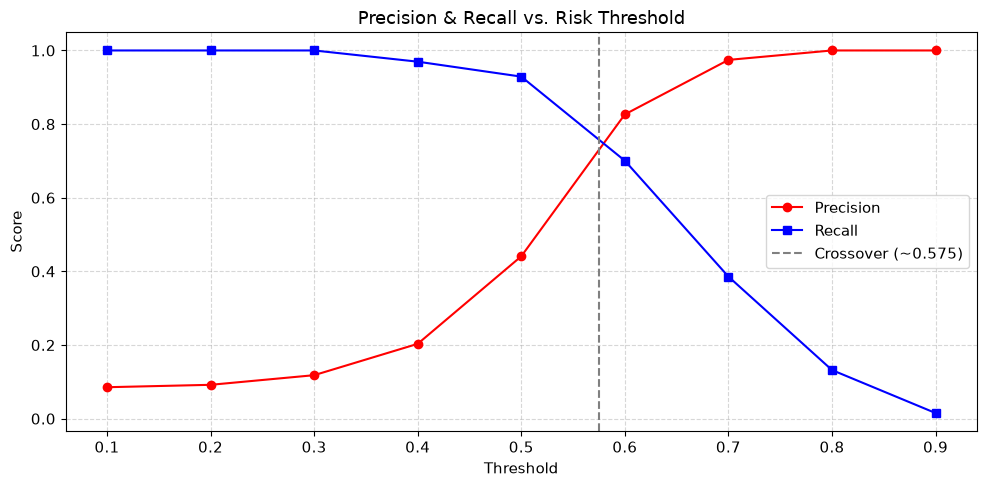

In [14]:
thresholds = np.arange(0.1, 1.0, 0.1)
precisions, recalls = [], []

for th in thresholds:
    pred = df_clean_suvidha['risk_score'] >= th
    tp = (df_clean_suvidha['actual_default'] & pred).sum()
    fp = ((~df_clean_suvidha['actual_default']) & pred).sum()
    fn = (df_clean_suvidha['actual_default'] & (~pred)).sum()
    precisions.append(tp / (tp + fp) if (tp + fp) > 0 else 0)
    recalls.append(tp / (tp + fn) if (tp + fn) > 0 else 0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresholds, precisions, marker='o', color='red', label='Precision')
ax.plot(thresholds, recalls, marker='s', color='blue', label='Recall')
ax.axvline(0.575, color='gray', linestyle='--', label='Crossover (~0.575)')
ax.set_title("Precision & Recall vs. Risk Threshold")
ax.set_xlabel("Threshold")
ax.set_ylabel("Score")
ax.set_xticks(thresholds)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


**Answer:** The curves cross at threshold ~0.575 (where both equal ~77%). Below 0.575, the business prioritizes loss prevention (higher recall); above 0.575, it prioritizes officer efficiency (higher precision).

### Q15. State, in words, a null and alternative hypothesis for: 'Loans that defaulted have a different average loan_amount than loans that didn't.'

**Hypotheses:**
- Null Hypothesis (H0): The average loan amount of defaulted loans is equal to the average loan amount of non-defaulted loans.
- Alternative Hypothesis (H1): The average loan amount of defaulted loans is different from the average loan amount of non-defaulted loans.


### Q16. Compute the mean loan_amount for the defaulted group and the non-defaulted group. Is there an apparent difference?

In [15]:
mean_amt_def = df_clean_suvidha[df_clean_suvidha['actual_default']]['loan_amount'].mean()
mean_amt_non = df_clean_suvidha[~df_clean_suvidha['actual_default']]['loan_amount'].mean()
print(f"Defaulted mean: ₹{mean_amt_def:,.2f}")
print(f"Non-defaulted mean: ₹{mean_amt_non:,.2f}")
print(f"Apparent difference: ₹{mean_amt_def - mean_amt_non:,.2f}")


Defaulted mean: ₹96,899.91
Non-defaulted mean: ₹92,408.81
Apparent difference: ₹4,491.10


### Q17. Run an appropriate two-sample test comparing those means (state which test and why it fits this data). Report the test statistic and p-value.

In [16]:
def_amt = df_clean_suvidha[df_clean_suvidha['actual_default']]['loan_amount']
non_amt = df_clean_suvidha[~df_clean_suvidha['actual_default']]['loan_amount']

t_stat, p_val = stats.ttest_ind(def_amt, non_amt, equal_var=False)
print(f"Welch's t-test statistic: {t_stat:.4f}, p-value: {p_val:.4f}")


Welch's t-test statistic: 1.3588, p-value: 0.1756


**Answer:** Welch's two-sample t-test was chosen because the groups have unequal sample sizes (197 vs 2,142) and unequal variances. Result: t = 1.3588, p = 0.1756.

### Q18. At α = 0.05, do you reject or fail to reject the null? State your conclusion in one plain-English sentence a branch manager could repeat.

**Answer:** At α = 0.05, fail to reject the null hypothesis (p = 0.1756 > 0.05). Conclusion: There is no statistically significant evidence that borrowers who default take out different loan amounts than borrowers who pay on time.

### Q19. Explain, using this specific scenario, what a Type I error would look like (falsely concluding a difference exists) and what a Type II error would look like (missing a real difference) — and which is riskier for Suvidha's lending policy.

**Answer:** A Type I error would mean falsely concluding loan size affects default, leading Suvidha to set unnecessary loan caps and turn away good business. A Type II error would mean missing a real link between loan size and default, leading Suvidha to keep disbursing large loans that default. Type II error is riskier as it directly threatens capital solvency.

### Q20. Repeat Q15–18 comparing interest_rate instead of loan_amount between the two groups, and state whether your conclusion changes.

In [17]:
def_rate = df_clean_suvidha[df_clean_suvidha['actual_default']]['interest_rate']
non_rate = df_clean_suvidha[~df_clean_suvidha['actual_default']]['interest_rate']

t_stat_r, p_val_r = stats.ttest_ind(def_rate, non_rate, equal_var=False)
print(f"Defaulted mean rate: {def_rate.mean():.2f}%")
print(f"Non-defaulted mean rate: {non_rate.mean():.2f}%")
print(f"Welch's t-stat: {t_stat_r:.4f}, p-value: {p_val_r:.4f}")


Defaulted mean rate: 14.80%
Non-defaulted mean rate: 14.46%
Welch's t-stat: 1.5778, p-value: 0.1160


**Answer:** p = 0.1160 > 0.05. Fail to reject the null; conclusion does not change. Interest rate does not significantly differentiate defaulters from non-defaulters.

### Q21. Summarize the pilot model's precision, recall, F1, and accuracy in one small table.

In [18]:
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1-Score'],
    'Value': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%", f"{recall*100:.2f}%", f"{specificity*100:.2f}%", f"{f1*100:.2f}%"]
})
print(metrics_df.to_string(index=False))


     Metric  Value
   Accuracy 96.41%
  Precision 86.93%
     Recall 67.51%
Specificity 99.07%
   F1-Score 76.00%


### Q22. Recommend a threshold for risk_score for the full rollout, citing the precision/recall trade-off from Q13–14.

In [19]:
pred_05 = df_clean_suvidha['risk_score'] >= 0.50
tp_05 = (df_clean_suvidha['actual_default'] & pred_05).sum()
fp_05 = ((~df_clean_suvidha['actual_default']) & pred_05).sum()
fn_05 = (df_clean_suvidha['actual_default'] & (~pred_05)).sum()

print(f"Threshold 0.50 -> Recall: {tp_05/(tp_05+fn_05)*100:.2f}%, Precision: {tp_05/(tp_05+fp_05)*100:.2f}%, False Alarms: {fp_05}")


Threshold 0.50 -> Recall: 92.89%, Precision: 44.10%, False Alarms: 232


**Recommendation:** Recommend threshold 0.50. This increases recall to 92.89% (catching 183 of 197 defaults) with 44.10% precision, producing ~2.5 follow-up calls per day per branch—a sustainable operational workload.

### Q23. Name one non-statistical risk of lowering the threshold too far (e.g. officer fatigue from false alarms) that the numbers alone won't show.

**Answer:** Officer fatigue and borrower alienation. Officers develop alert fatigue when most flagged calls are safe borrowers, while contacting creditworthy borrowers with default warnings creates customer friction and damages institutional trust.

### Q24. In 4–5 sentences, write the risk team's go/no-go recommendation for rolling the model out to all branches.

**Recommendation:** The risk team recommends a conditional go for branch-wide rollout, provided the operational cutoff is lowered from ~0.61 to 0.50. The pilot proved the model's predictive ability (87% precision), but its conservative threshold allowed 64 defaults to slip through, causing ₹6.2M in write-offs. Shifting to 0.50 captures 92.9% of defaults with a manageable workload of 2–3 calls daily per branch. Rollout should include standardized call scripts and weekly review of collection conversion rates.

### Q25. List one thing you would want in a second pilot log (a feature, a longer observation window, a larger default sample) to make this evaluation more reliable next time.

**Answer:** External credit bureau scores (e.g. CIBIL/Equifax microfinance scores) and prior repayment history (days past due in earlier loan cycles), combined with extending the tracking window from 90 to 180 days.